In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

points = pd.read_parquet(PROCESSED / "points_context.parquet")
shots = pd.read_parquet(PROCESSED / "shots_context.parquet")

print("Points:", points.shape)
print("Shots: ", shots.shape)

Points: (1353711, 21)
Shots:  (5308401, 14)


In [2]:
# The parser stored how each point ended, but not which shot ended it.
# The final shot of a rally carries the point outcome; every earlier shot
# simply kept the rally alive. This creates the 4-class target for SQ2.
shots = shots.merge(points[["match_id", "Pt", "point_outcome", "rally_length"]],
                    on=["match_id", "Pt"], how="left")

shots["shot_outcome"] = np.where(shots["shot_number"] == shots["rally_length"],
                                 shots["point_outcome"],
                                 "in_play")

# The majority class sets the accuracy floor any model must beat.
distribution = shots["shot_outcome"].value_counts(normalize=True)
print(distribution.round(3))
print(f"\nMajority-class baseline: {distribution.max():.1%}")

shot_outcome
in_play           0.769
unforced_error    0.087
forced_error      0.081
winner            0.063
Name: proportion, dtype: float64

Majority-class baseline: 76.9%


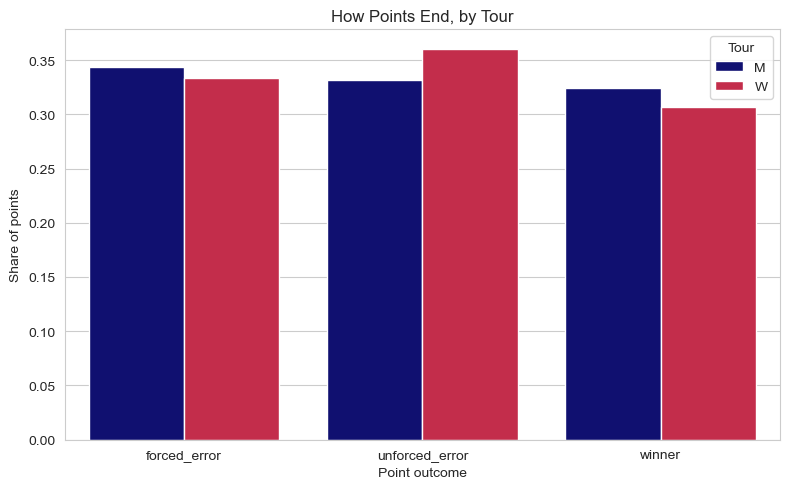

In [3]:
# How points end overall, split by tour. This is the base rate every later
# comparison is measured against.
outcome_by_gender = (points.groupby("gender")["point_outcome"]
                     .value_counts(normalize=True)
                     .rename("share").reset_index())

plt.figure(figsize=(8, 5))
sns.barplot(data=outcome_by_gender, x="point_outcome", y="share", hue="gender",
            palette=["navy", "crimson"])
plt.title("How Points End, by Tour")
plt.xlabel("Point outcome")
plt.ylabel("Share of points")
plt.legend(title="Tour")
plt.tight_layout()
plt.savefig(FIGURES / "outcome_by_gender.png", dpi=150)
plt.show()

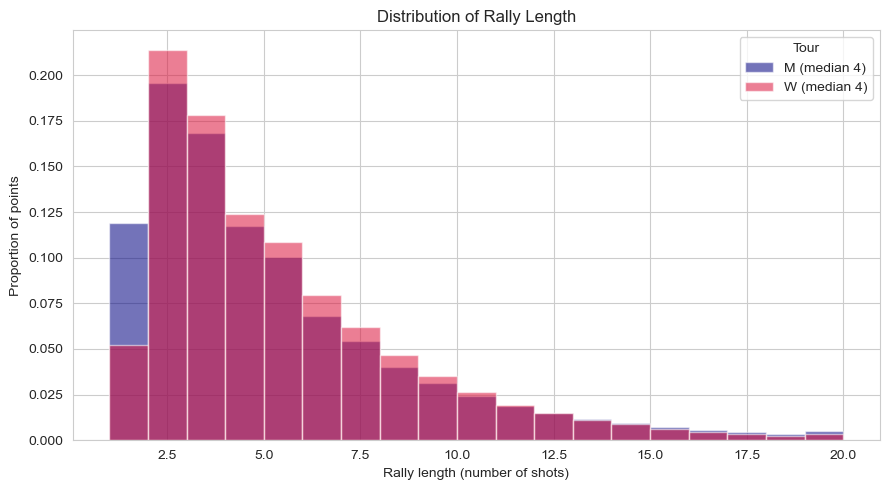

In [4]:
# Rally length is heavily right-skewed: most points are decided early.
# We cap the axis at 20 shots because the long tail is visually useless.
plt.figure(figsize=(9, 5))
for tour, colour in [("M", "navy"), ("W", "crimson")]:
    subset = points.loc[points["gender"] == tour, "rally_length"]
    plt.hist(subset, bins=range(1, 21), density=True, alpha=0.55,
             color=colour, label=f"{tour} (median {subset.median():.0f})")

plt.title("Distribution of Rally Length")
plt.xlabel("Rally length (number of shots)")
plt.ylabel("Proportion of points")
plt.legend(title="Tour")
plt.tight_layout()
plt.savefig(FIGURES / "rally_length_distribution.png", dpi=150)
plt.show()

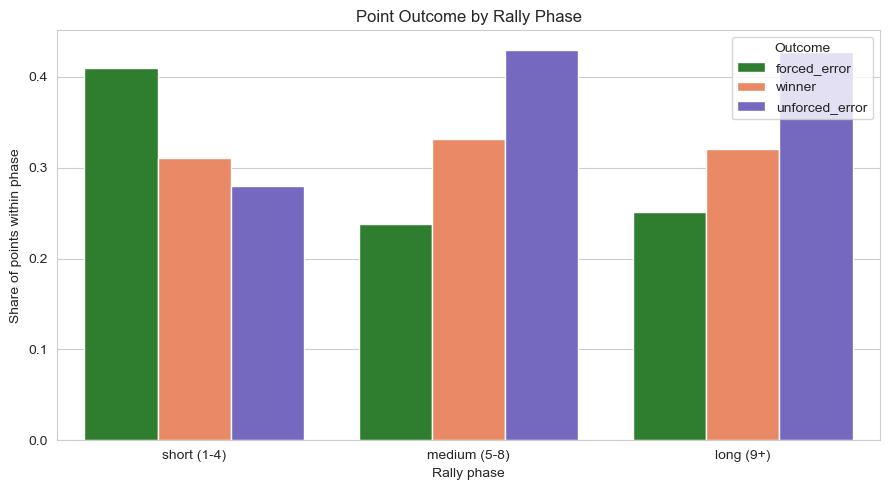

In [5]:
# Rally phase buckets follow the project brief: short, medium, long.
points["rally_phase"] = pd.cut(points["rally_length"],
                               bins=[0, 4, 8, np.inf],
                               labels=["short (1-4)", "medium (5-8)", "long (9+)"])

phase_outcome = (points.groupby("rally_phase", observed=True)["point_outcome"]
                 .value_counts(normalize=True)
                 .rename("share").reset_index())

plt.figure(figsize=(9, 5))
sns.barplot(data=phase_outcome, x="rally_phase", y="share", hue="point_outcome",
            palette=["forestgreen", "coral", "slateblue"])
plt.title("Point Outcome by Rally Phase")
plt.xlabel("Rally phase")
plt.ylabel("Share of points within phase")
plt.legend(title="Outcome")
plt.tight_layout()
plt.savefig(FIGURES / "outcome_by_rally_phase.png", dpi=150)
plt.show()

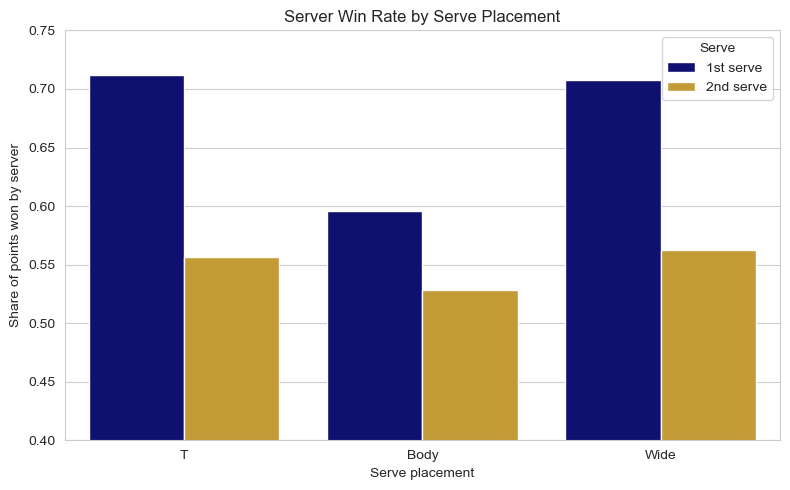

In [6]:
# Server win rate by placement, separated by serve number. First and second
# serves must not be pooled: they are played with different risk appetite.
points["server_won"] = (points["point_winner"] == points["server"])
points["serve_number"] = np.where(points["is_second_serve"], "2nd serve", "1st serve")

serve_effect = (points.dropna(subset=["serve_direction"])
                .groupby(["serve_number", "serve_direction"], observed=True)["server_won"]
                .mean().rename("win_rate").reset_index())

plt.figure(figsize=(8, 5))
sns.barplot(data=serve_effect, x="serve_direction", y="win_rate", hue="serve_number",
            palette=["navy", "goldenrod"], order=["T", "Body", "Wide"])
plt.title("Server Win Rate by Serve Placement")
plt.xlabel("Serve placement")
plt.ylabel("Share of points won by server")
plt.ylim(0.4, 0.75)
plt.legend(title="Serve")
plt.tight_layout()
plt.savefig(FIGURES / "serve_placement_win_rate.png", dpi=150)
plt.show()

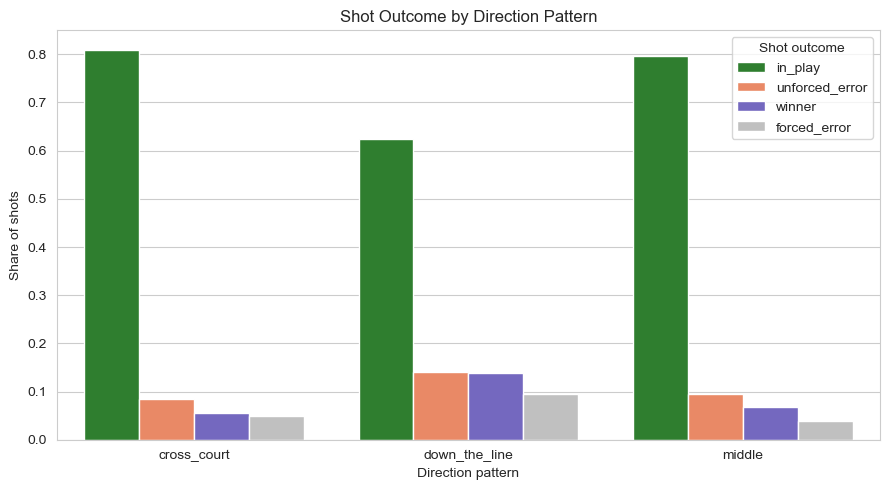

In [7]:
# Cross-court vs down-the-line. This is the core risk-reward comparison
# behind the main research question.
pattern_outcome = (shots.dropna(subset=["direction_pattern"])
                   .groupby("direction_pattern", observed=True)["shot_outcome"]
                   .value_counts(normalize=True)
                   .rename("share").reset_index())

plt.figure(figsize=(9, 5))
sns.barplot(data=pattern_outcome, x="direction_pattern", y="share", hue="shot_outcome",
            palette=["forestgreen", "coral", "slateblue", "silver"],
            order=["cross_court", "down_the_line", "middle"])
plt.title("Shot Outcome by Direction Pattern")
plt.xlabel("Direction pattern")
plt.ylabel("Share of shots")
plt.legend(title="Shot outcome")
plt.tight_layout()
plt.savefig(FIGURES / "outcome_by_direction_pattern.png", dpi=150)
plt.show()